In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv(r'G:\My Drive\Data Science\smartcity\data\aqi\air_quality_historical.csv')
data


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,01-08-2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,02-08-2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,03-08-2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,04-08-2022,42.084211,25.989474,407.578947,29.210526,47.605263,60.684211,0.469474,7.105263,2.131579,NaN,NaN
4,05-08-2022,25.287500,16.737500,355.250000,27.179167,39.725000,41.375000,0.298750,1.458333,1.041667,67.157895,42.684211
...,...,...,...,...,...,...,...,...,...,...,...,...
1293,14-02-2026,90.800000,89.020833,813.416667,26.358333,45.333333,166.375000,0.755833,1.875000,1.372917,178.875000,102.041667
1294,15-02-2026,61.745833,60.012500,713.500000,22.245833,30.070833,141.166667,0.677083,2.250000,1.410417,168.500000,99.958333
1295,16-02-2026,48.525000,46.066667,692.708333,19.129167,32.491667,126.708333,0.687083,2.833333,1.435417,148.958333,81.750000
1296,17-02-2026,42.066667,37.933333,540.208333,14.162500,22.445833,121.083333,0.771667,3.916667,1.352083,124.666667,76.250000


In [4]:
data.isnull().sum()


date                     0
pm10                     3
pm2_5                    3
carbon_monoxide          3
nitrogen_dioxide         3
sulphur_dioxide          3
ozone                    3
aerosol_optical_depth    3
dust                     3
uv_index                 3
us_aqi                   4
european_aqi             4
dtype: int64

In [6]:
(data.isnull().sum() / len(data) * 100).sort_values(ascending=False)

us_aqi                   0.308166
european_aqi             0.308166
pm10                     0.231125
pm2_5                    0.231125
carbon_monoxide          0.231125
nitrogen_dioxide         0.231125
sulphur_dioxide          0.231125
ozone                    0.231125
aerosol_optical_depth    0.231125
dust                     0.231125
uv_index                 0.231125
date                     0.000000
dtype: float64

In [7]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data['date'] = pd.to_datetime(
    data_aqi['date'],
    format='%d-%m-%Y'
)

NameError: name 'data_aqi' is not defined

In [8]:
data["date"] = pd.to_datetime(
    data["date"],
    format="%d-%m-%Y"
)

In [9]:
data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["month_name"] = data["date"].dt.month_name()
data["day_of_week"] = data["date"].dt.day_name()
data["day"] = data["date"].dt.day

In [21]:
data.to_csv(r'G:\My Drive\Data Science\smartcity\data\aqi\aqi_cleaned.csv', index=False)

In [10]:
print("Start:", data["date"].min())
print("End:", data["date"].max())

Start: 2022-08-01 00:00:00
End: 2026-02-18 00:00:00


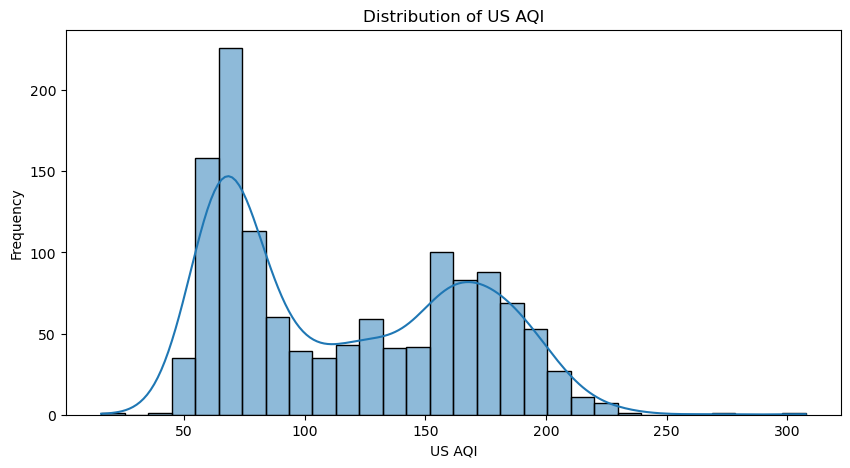

In [11]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data["us_aqi"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of US AQI")
plt.xlabel("US AQI")
plt.ylabel("Frequency")
plt.show()

### AQI over time


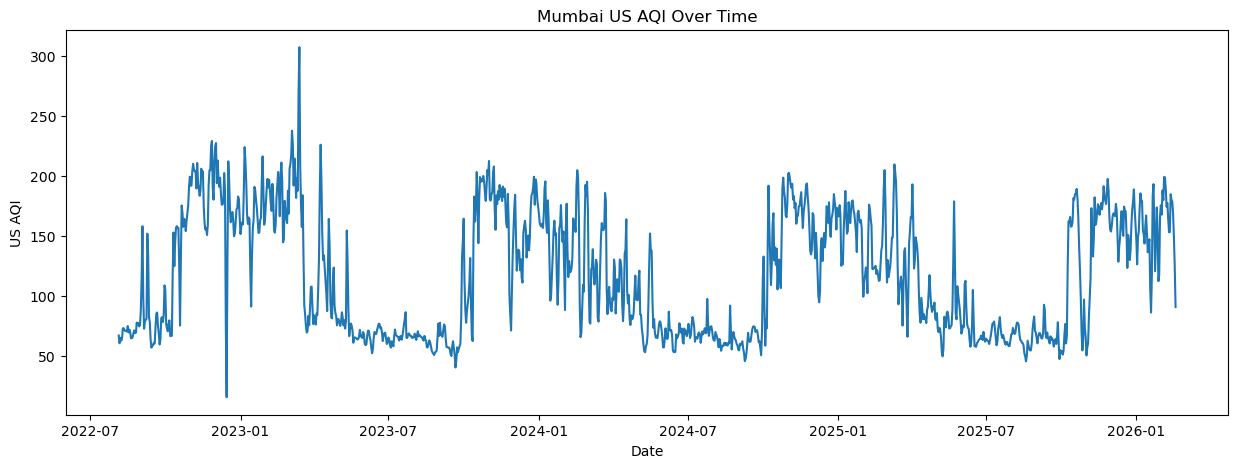

In [12]:
plt.figure(figsize=(15, 5))

sns.lineplot(
    data=data,
    x="date",
    y="us_aqi"
)

plt.title("Mumbai US AQI Over Time")
plt.xlabel("Date")
plt.ylabel("US AQI")

plt.show()

### Monthly AQI analysis

In [13]:
monthly_aqi = (
    data.groupby("month_name")["us_aqi"]
    .mean()
)

In [14]:
month_order = [
    "January", "February", "March",
    "April", "May", "June",
    "July", "August", "September",
    "October", "November", "December"
]

monthly_aqi = (
    data.groupby("month_name")["us_aqi"]
    .mean()
    .reindex(month_order)
)

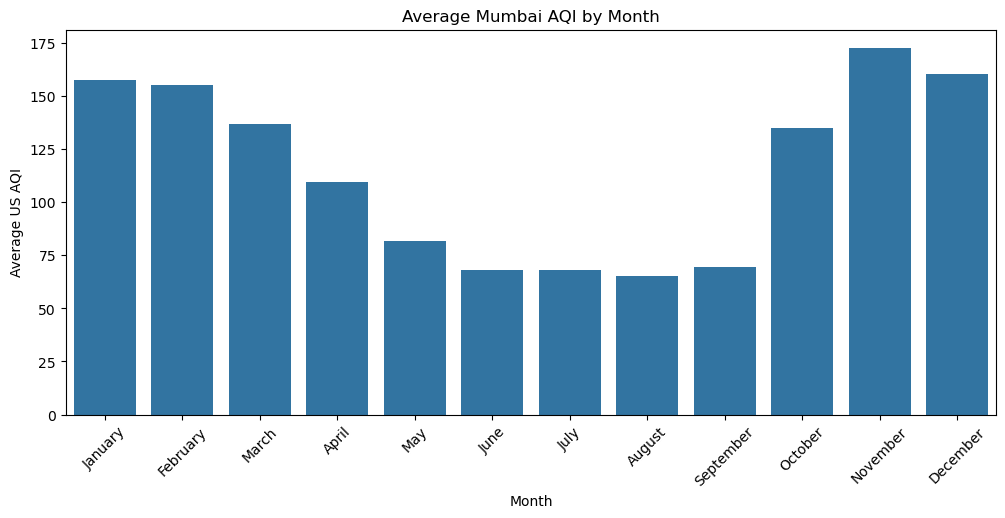

In [15]:
plt.figure(figsize=(12, 5))

sns.barplot(
    x=monthly_aqi.index,
    y=monthly_aqi.values
)

plt.title("Average Mumbai AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average US AQI")

plt.xticks(rotation=45)
plt.show()

### Pollutants over time

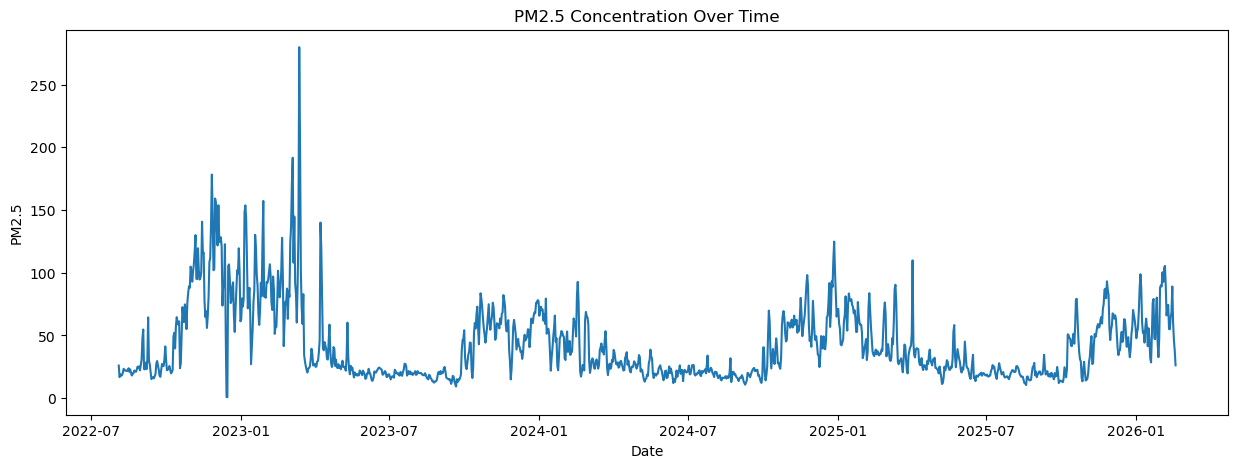

In [16]:
plt.figure(figsize=(15, 5))

sns.lineplot(
    data=data,
    x="date",
    y="pm2_5"
)

plt.title("PM2.5 Concentration Over Time")
plt.xlabel("Date")
plt.ylabel("PM2.5")

plt.show()

### Pollutants vs AQI

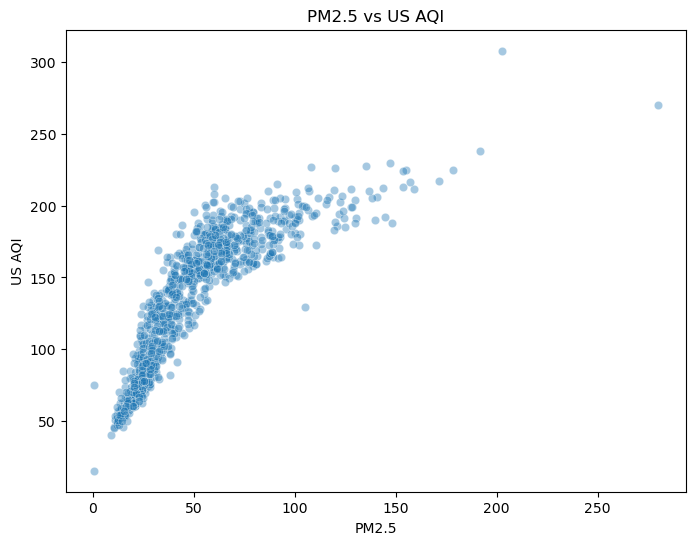

In [19]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=data,
    x="pm2_5",
    y="us_aqi",
    alpha=0.4
)

plt.title("PM2.5 vs US AQI")
plt.xlabel("PM2.5")
plt.ylabel("US AQI")

plt.show()

### Correlation

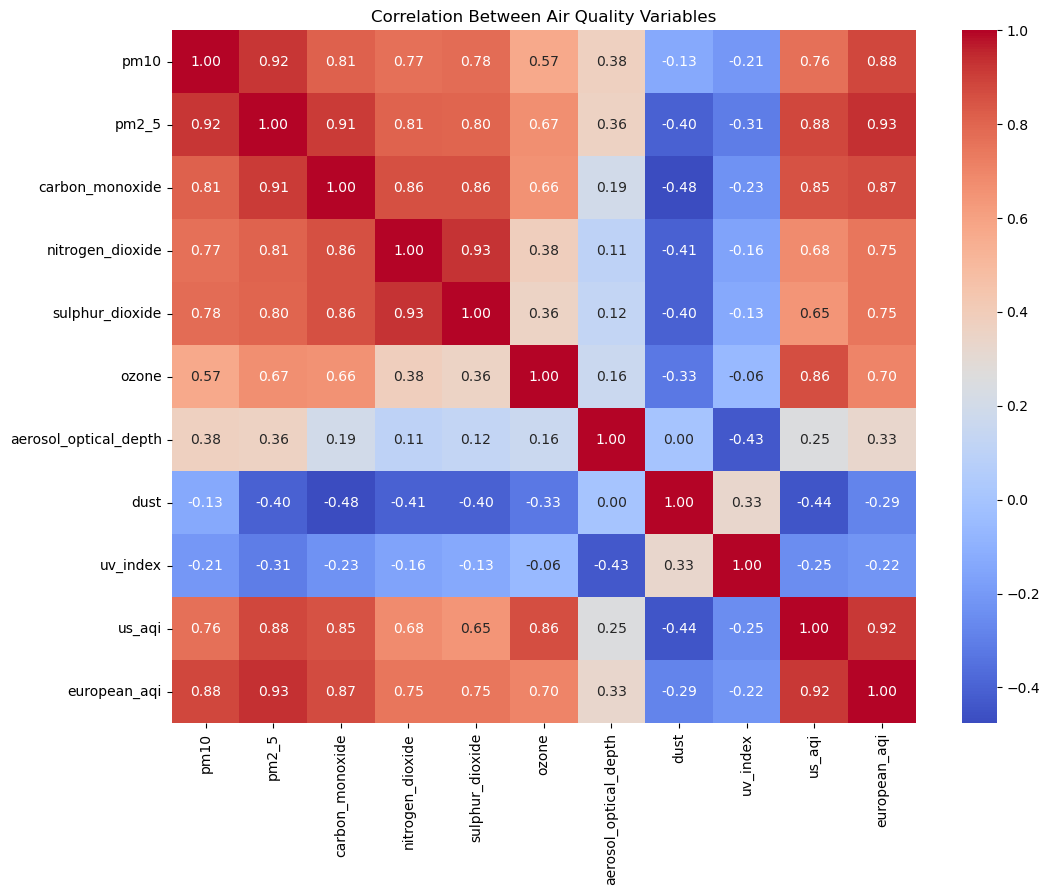

In [17]:
numeric_cols = [
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "aerosol_optical_depth",
    "dust",
    "uv_index",
    "us_aqi",
    "european_aqi"
]

corr = data[numeric_cols].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Air Quality Variables")

plt.show()